In [59]:
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [60]:
df = yf.download("AAPL",start="2016-01-01",end="2026-01-01",auto_adjust=False,multi_level_index=False)

[*********************100%***********************]  1 of 1 completed


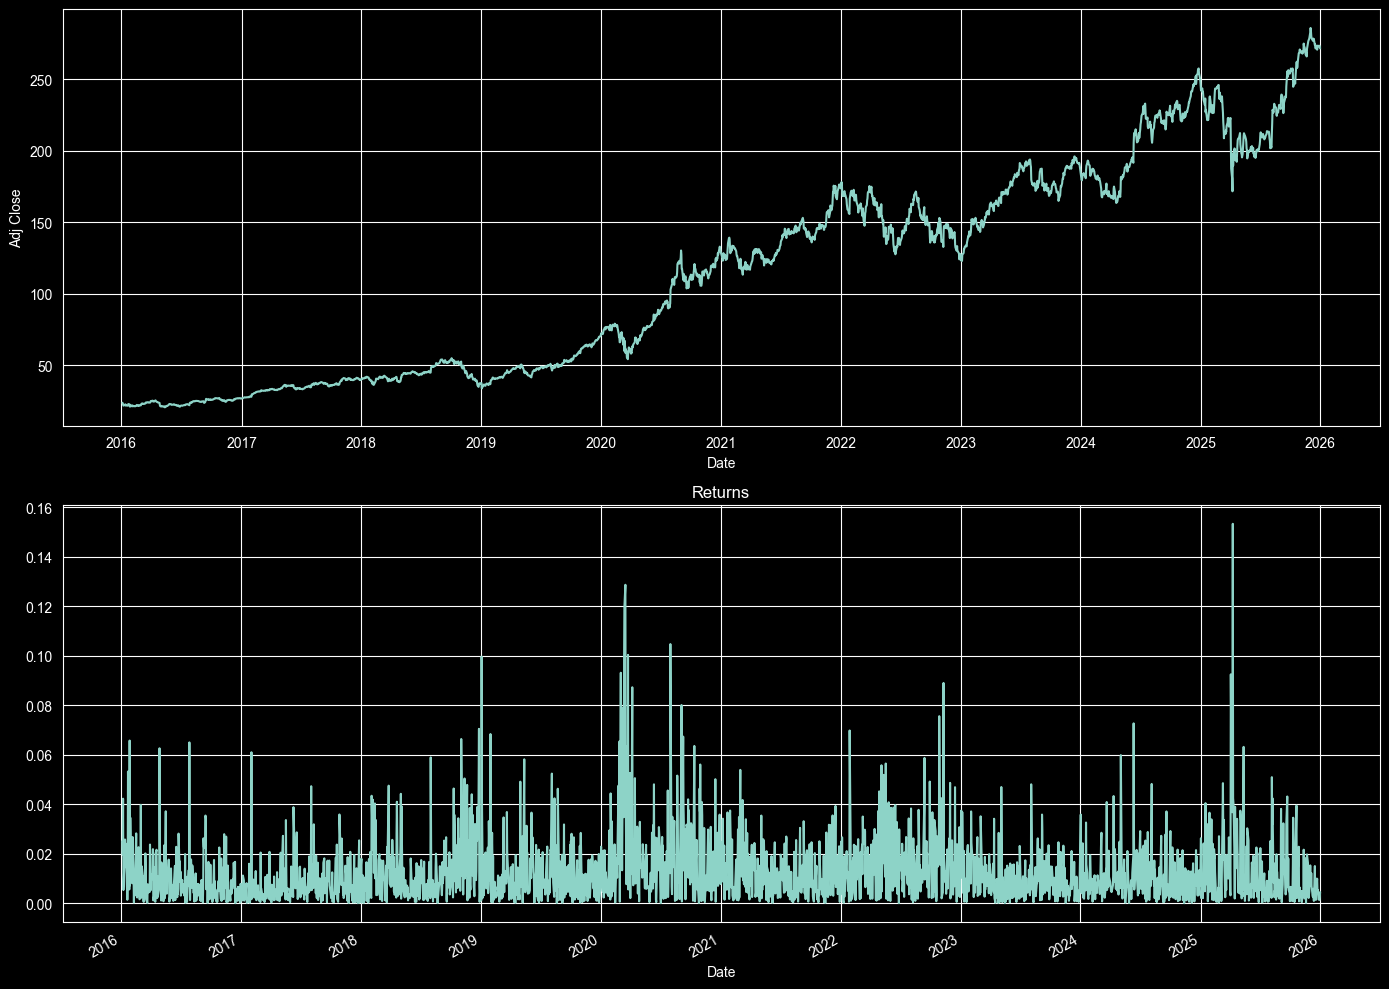

In [61]:
# Creating Returns to make data stationarity and removing trend,season and pattern

df['returns'] = df['Adj Close'].pct_change()
df['abs_returns'] = df['returns'].abs()
# Plotting Price and Daily Returns

# Plotting close price
fig,(ax1,ax2) = plt.subplots(2,1,figsize=(14,10))
sns.lineplot(df['Adj Close'], ax=ax1)
plt.title('Closing Prices')

# Plotting daily returns
df['abs_returns'].plot(ax=ax2)
plt.title('Returns')

plt.tight_layout()
plt.show()

# Dropping columns and NaNs
df = df[['returns', 'abs_returns']]
df.dropna(inplace=True)

In [62]:
# Adfuller test for checking P value using it is stationary
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['abs_returns'])

print("p-value:{:.2e}".format(result[1]))

p-value:2.41e-09


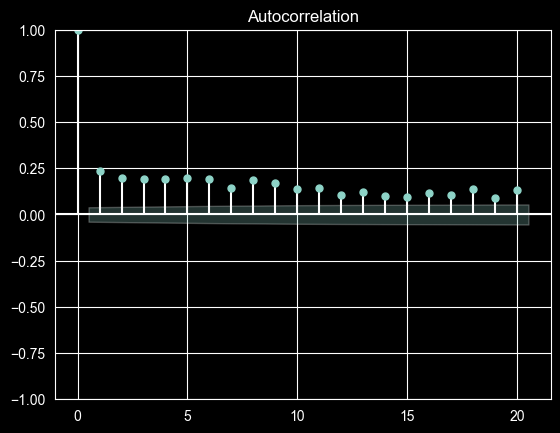

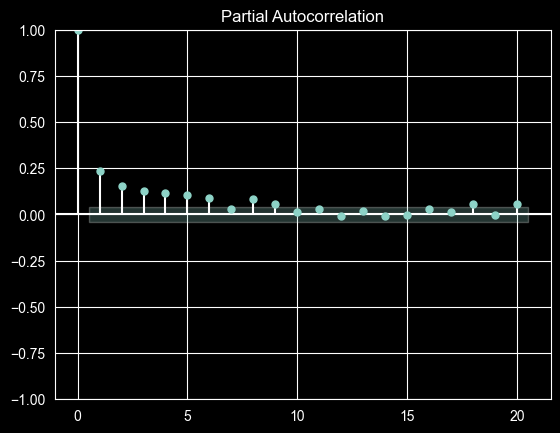

In [63]:
# plotting ACF AND PACF
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

plot_acf(df['abs_returns'], lags=20)
plt.title('Autocorrelation')


plot_pacf(df['abs_returns'], lags=20)
plt.title('Partial Autocorrelation')

plt.show()

# Buy and Hold

In [64]:
# Calculating Buy and Hold for compairing with Models which i gonna train
df["Buy and Hold"] = (1 + df['returns']).cumprod()
print("Buy and Hold",df['Buy and Hold'].iloc[-1])

Buy and Hold 11.44521387246632


# AR model